In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
import random
import math
from graphviz import Digraph
import matplotlib.pyplot as plt

random.seed(22) #For reproducibility

In [2]:
#Define the core scalar class
class Scalar :

    def __init__(self, data, parents=()):
        #Every Scalar has a value and a corresponding gradient
        self.data = data
        self.grad = 0.0

        #Store the parents of each scalar in an unordered set
        self.prev = set(parents)

        #A function that computes the chain rule during backpropagation
        self._backward = lambda : None

    def __add__(self, other):
        other = other if isinstance(other, Scalar) else Scalar(other)
        out = Scalar(self.data + other.data, (self, other))

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Scalar) else Scalar(other)
        out = Scalar(self.data * other.data, (self, other))

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out    


    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Scalar(self.data**other, (self,))

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out
    
    def log(self):
        out = Scalar(math.log(self.data), (self,))

        def _backward():
            self.grad += (1 / self.data) * out.grad
        out._backward = _backward

        return out
        
    def __neg__(self): # -self
        return self * -1

    def __radd__(self, other): # other + self
        return self + other

    def __sub__(self, other): # self - other
        return self + (-other)

    def __rsub__(self, other): # other - self
        return other + (-self)

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

    def tanh(self):
        out = Scalar(math.tanh(self.data), (self,))

        def _backward():
            self.grad += (1-math.tanh(self.data)**2) * out.grad
        out._backward = _backward
        return out
    
    def sigmoid(self):
        if self.data < -500:  # Prevent underflow
            result = 0.0
        elif self.data > 500:  # Prevent overflow  
         result = 1.0
        else:
            result = 1 / (1 + math.exp(-self.data))
        
        out = Scalar(result, (self,))
        
        def _backward():
            self.grad += (result*(1-result)) * out.grad
        out._backward = _backward
        return out
    
    
    def relu(self):
        out = Scalar(0 if self.data < 0 else self.data, (self,))

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out
    
    def backward(self):
        #Order the nodes from right to left via a topological sort done DFS style
        #Recursively start at the root node and go backwards, appending each node's children before itself, to ensure topological order
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v.prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        #Set the output node's gradient to 1, since for any function x, dx/dx is 1
        self.grad = 1.0

        #You need to start backpropagation at the output node, so reverse the topological sort then go backwards
        for node in reversed(topo):
            node._backward()


    def __repr__(self):
        return f"Scalar(data={self.data}, gradient={self.grad})"

In [3]:
#Define the Neural Network Structures
class Neuron:
    def __init__(self, dimNeurons, activation='relu'):
        self.weights = [Scalar(random.uniform(-1,1)) for _ in range(dimNeurons)]
        self.bias = Scalar(random.uniform(-1,1))
        self.activation = activation

    def __call__(self, x):
        # Dot the inputs to the neuron with weights, and add bias
        activation = sum((wi*xi for wi, xi in zip(self.weights, x)), self.bias)
        
        # Apply activation function
        if self.activation == 'relu':
            return activation.relu()
        elif self.activation == 'sigmoid':
            return activation.sigmoid()
        elif self.activation == 'tanh':
            return activation.tanh()
        else:
            return activation  # linear activation
    
    def parameters(self):
        return self.weights + [self.bias]
    
class Layer:
    def __init__(self, dimNeurons, numNeurons, activation='relu'):
        # Initialize a list of n-dimensional neurons where n = dimNeurons
        self.neurons = [Neuron(dimNeurons, activation) for _ in range(numNeurons)]

    def __call__(self, x):
        outputs = [n(x) for n in self.neurons]
        return outputs[0] if len(outputs) == 1 else outputs
    
    def parameters(self):
        params = []
        for neuron in self.neurons:
            params.extend(neuron.parameters())
        return params

class MLP:
    def __init__(self, dimNeurons, numNeurons, hidden_activation='relu', output_activation='sigmoid'):
        layerSize = [dimNeurons] + numNeurons
        self.layers = []
        
        # Create hidden layers with specified activation
        for i in range(len(numNeurons) - 1):
            self.layers.append(Layer(layerSize[i], layerSize[i+1], hidden_activation))
        
        # Create output layer with output activation
        if len(numNeurons) > 0:
            self.layers.append(Layer(layerSize[-2], layerSize[-1], output_activation))

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
        
    def parameters(self):
        params = []
        for layer in self.layers:
            params.extend(layer.parameters())
        return params

In [15]:
#Define the training functions
def mean_squared_error(y_true, y_pred):
    diff = y_pred - y_true
    return diff * diff

def train_mlp(model, X, y, batch_size, epochs, learning_rate, loss_fn=mean_squared_error,lr_decay_type='exponential', lr_decay_rate=0.95, lr_decay_step=10, lr_min=1e-6):
    initial_lr = learning_rate
    for epoch in range(epochs):
        # Update learning rate based on decay strategy
        if lr_decay_type == 'exponential':
            # Exponential decay: lr = initial_lr * (decay_rate ^ epoch)
            current_lr = max(initial_lr * (lr_decay_rate ** epoch), lr_min)
        
        elif lr_decay_type == 'step':
            # Step decay: reduce lr every lr_decay_step epochs
            current_lr = max(initial_lr * (lr_decay_rate ** (epoch // lr_decay_step)), lr_min)
        
        elif lr_decay_type == 'cosine':
            # Cosine annealing: smooth cosine decay
            current_lr = max(lr_min + (initial_lr - lr_min) * 
                           (1 + math.cos(math.pi * epoch / epochs)) / 2, lr_min)
        
        elif lr_decay_type == 'linear':
            # Linear decay: linearly decrease to lr_min
            current_lr = max(initial_lr - (initial_lr - lr_min) * epoch / epochs, lr_min)
        
        else:
            current_lr = learning_rate  # No decay
        total_loss = Scalar(0)
        num_batches = 0
        
        # Create mini-batches
        indices = list(range(len(X)))
        random.shuffle(indices)
        
        for start_idx in range(0, len(X), batch_size):
            batch_indices = indices[start_idx:start_idx + batch_size]
            batch_X = [X[i] for i in batch_indices]
            batch_y = [y[i] for i in batch_indices]
            
            # Clear gradients before forward pass
            for p in model.parameters():
                p.grad = 0.0
            
            batch_loss = Scalar(0)
            
            # Forward pass
            for x, y_true in zip(batch_X, batch_y):
                y_pred = model(x)
                loss = loss_fn(y_true, y_pred)
                batch_loss = batch_loss + loss
            
            # Compute average batch loss
            batch_loss = batch_loss * (Scalar(1.0) / len(batch_indices))
            
            # Backward pass
            batch_loss.backward()
            
            # Update parameters
            for p in model.parameters():
                if p.grad is not None:
                    p.data -= learning_rate * p.grad
            
            total_loss = total_loss + batch_loss
            num_batches += 1
        
        # Compute average epoch loss
        avg_epoch_loss = total_loss * (Scalar(1.0) / num_batches)
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_epoch_loss.data:.6f}")

In [16]:
#Define a way to visualize the neural network
#Perform a depth first search starting at the node we call trace at to gather all the nodes
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v.prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges


def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB'], "Invalid rankdir value. Use 'LR' or 'TB'."
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir})
    
    for n in nodes:
        # Label nodes with just their data and gradient
        node_label = "{ data %.4f | grad %.4f }" % (n.data, n.grad)
        dot.node(name=str(id(n)), label=node_label, shape='record')
    
    for n1, n2 in edges:
        # Create edges between nodes
        dot.edge(str(id(n1)), str(id(n2)))
    
    return dot

In [17]:
# Load the heart disease dataset
dataset = pd.read_csv("heart.csv")

print(f"Dataset shape: {dataset.shape}")
print(f"Columns: {list(dataset.columns)}")
print(f"First few rows:")
dataset.head()

Dataset shape: (303, 14)
Columns: ['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh', 'exng', 'oldpeak', 'slp', 'caa', 'thall', 'output']
First few rows:


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [18]:
#Clean the dataset
targetColumn = "output"
inputColumnNames = dataset.columns.drop("output")
outputRows = dataset[targetColumn]
dataset.drop(targetColumn,axis=1,inplace=True)

#Clean data
#Normalize input data to between 0 and 1
scaler = MinMaxScaler()
scaler.fit(dataset)
transformedDataset = scaler.transform(dataset)

#Split the data into a training set and a testing set
xTrain, xTest, yTrain, yTest = train_test_split(transformedDataset, outputRows, test_size=0.25, random_state=0)
xTrain = xTrain.tolist()
yTrain = yTrain.tolist()
xTest = xTest.tolist()
yTest = yTest.tolist()

xTrainScalars = [[Scalar(val) for val in row] for row in xTrain]
yTrainScalars = [Scalar(val) for val in yTrain]
xTestScalars = [[Scalar(val) for val in row] for row in xTest]

In [21]:
#Build and train the model
model = MLP(13, [15, 15, 1], hidden_activation='relu', output_activation='sigmoid')

print("Starting training...")
train_mlp(model, xTrainScalars, yTrainScalars, batch_size=32, epochs=100, learning_rate=0.01, loss_fn=mean_squared_error, lr_decay_type='exponential', lr_decay_rate=0.90, lr_decay_step=10, lr_min=1e-6)

Starting training...
Epoch 1/100, Loss: 0.245182
Epoch 2/100, Loss: 0.240695
Epoch 3/100, Loss: 0.241680
Epoch 4/100, Loss: 0.241123
Epoch 5/100, Loss: 0.221892
Epoch 6/100, Loss: 0.226697
Epoch 7/100, Loss: 0.222688
Epoch 8/100, Loss: 0.230278
Epoch 9/100, Loss: 0.215900
Epoch 10/100, Loss: 0.218580
Epoch 11/100, Loss: 0.213464
Epoch 12/100, Loss: 0.204759
Epoch 13/100, Loss: 0.204249
Epoch 14/100, Loss: 0.211120
Epoch 15/100, Loss: 0.216353
Epoch 16/100, Loss: 0.200486
Epoch 17/100, Loss: 0.210710
Epoch 18/100, Loss: 0.212456
Epoch 19/100, Loss: 0.204088
Epoch 20/100, Loss: 0.201054
Epoch 21/100, Loss: 0.189389
Epoch 22/100, Loss: 0.189965
Epoch 23/100, Loss: 0.198681
Epoch 24/100, Loss: 0.184136
Epoch 25/100, Loss: 0.194673
Epoch 26/100, Loss: 0.190631
Epoch 27/100, Loss: 0.190762
Epoch 28/100, Loss: 0.181214
Epoch 29/100, Loss: 0.185704
Epoch 30/100, Loss: 0.180696
Epoch 31/100, Loss: 0.181715
Epoch 32/100, Loss: 0.179792
Epoch 33/100, Loss: 0.198199
Epoch 34/100, Loss: 0.182766
Ep

In [22]:
#Test the model
yPredictions = [model(x) for x in xTestScalars]

#Pull the data property out of each Scalar
yPredictionsClean = [x.data for x in yPredictions]

#Push the data through a threshold to make it binary

yPredictionsFinal = [0 if x < 0.5 else 1 for x in yPredictionsClean]

cm = confusion_matrix(yTest, yPredictionsFinal)
accuracy = accuracy_score(yTest, yPredictionsFinal)

TN, FP, FN, TP = confusion_matrix(yTest, yPredictionsFinal).ravel()

print('\n=== RESULTS ===')
print(f'Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'True Positive(TP)  = {TP}')
print(f'False Positive(FP) = {FP}')
print(f'True Negative(TN)  = {TN}')
print(f'False Negative(FN) = {FN}')

print('\nConfusion Matrix:')
print(cm)



=== RESULTS ===
Accuracy: 0.7895 (78.95%)
True Positive(TP)  = 38
False Positive(FP) = 11
True Negative(TN)  = 22
False Negative(FN) = 5

Confusion Matrix:
[[22 11]
 [ 5 38]]


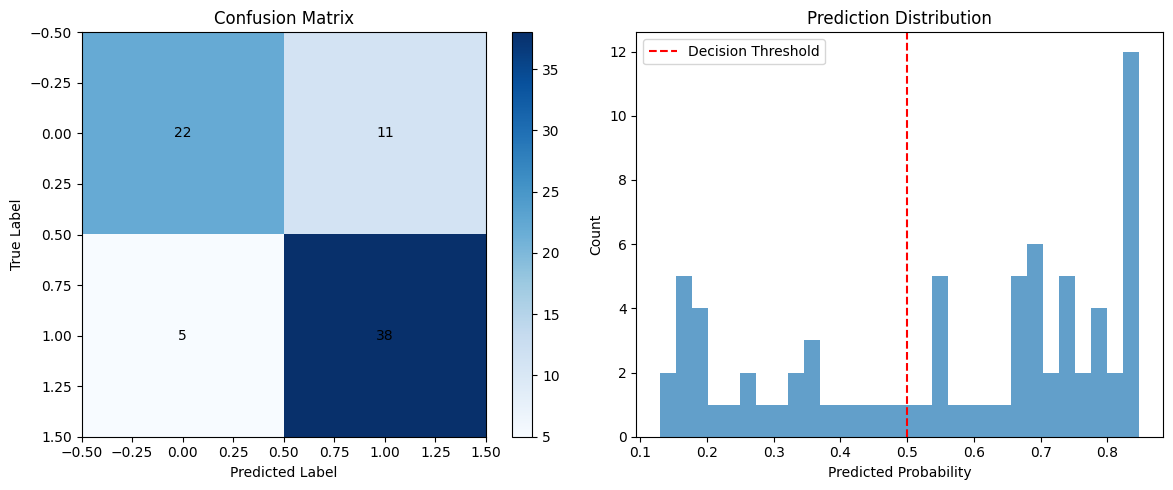

In [23]:
#Visualize Results
# Plot confusion matrix
plt.figure(figsize=(12, 5))

# Confusion matrix heatmap
plt.subplot(1, 2, 1)
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Add text annotations
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

# Prediction distribution
plt.subplot(1, 2, 2)
plt.hist(yPredictionsClean, bins=30, alpha=0.7)
plt.axvline(x=0.5, color='red', linestyle='--', label='Decision Threshold')
plt.title('Prediction Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()
plt.show()

Epoch 10/100, Loss: 0.793817
Epoch 20/100, Loss: 0.900432
Epoch 30/100, Loss: 0.572112
Epoch 40/100, Loss: 0.397789
Epoch 50/100, Loss: 0.547724
Epoch 60/100, Loss: 0.144019
Epoch 70/100, Loss: 0.174593
Epoch 80/100, Loss: 0.766282
Epoch 90/100, Loss: 0.185856
Epoch 100/100, Loss: 0.807454

=== PYTORCH RESULTS ===
Accuracy: 0.8158 (81.58%)
True Positive(TP)  = 36
False Positive(FP) = 7
True Negative(TN)  = 26
False Negative(FN) = 7

Confusion Matrix:
[[26  7]
 [ 7 36]]


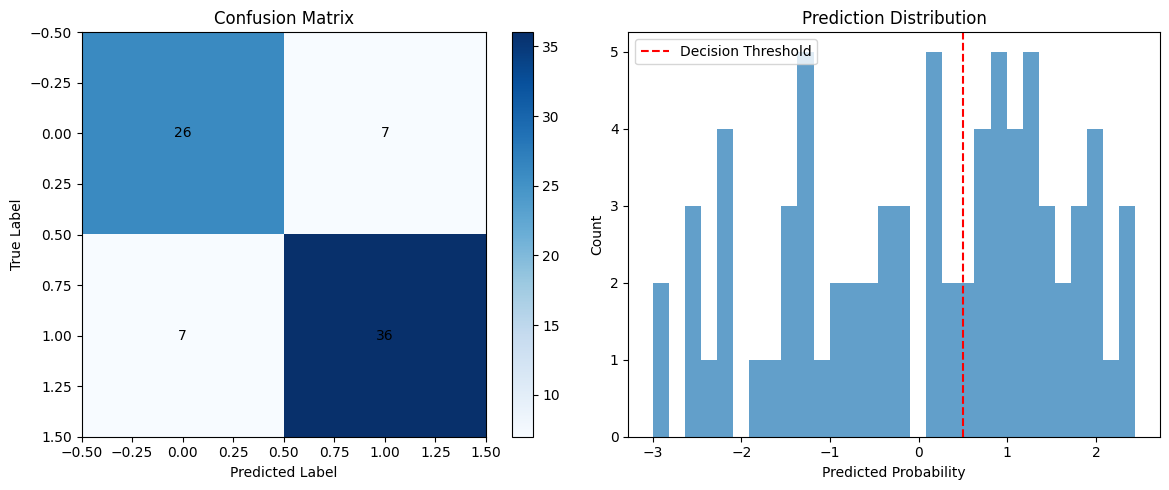

In [26]:
#Compare this with Pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

# --- Define MLP with BCE ---
class ScalarFlowMLP_BCE(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size=1):
        super().__init__()
        layers = []
        prev_size = input_size
        for h in hidden_sizes:
            linear = nn.Linear(prev_size, h)
            nn.init.uniform_(linear.weight, -1, 1)
            nn.init.uniform_(linear.bias, -1, 1)
            layers.append(linear)
            layers.append(nn.ReLU())
            prev_size = h
        # Output layer (no sigmoid)
        linear = nn.Linear(prev_size, output_size)
        nn.init.uniform_(linear.weight, -1, 1)
        nn.init.uniform_(linear.bias, -1, 1)
        layers.append(linear)
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x).view(-1)

# --- Load and preprocess data ---
dataset = pd.read_csv("heart.csv")
X = dataset.drop("output", axis=1).values
y = dataset["output"].values

scaler = MinMaxScaler()
X = scaler.fit_transform(X)

xTrain, xTest, yTrain, yTest = train_test_split(X, y, test_size=0.25, random_state=0)
xTrain = torch.FloatTensor(xTrain)
yTrain = torch.FloatTensor(yTrain)
xTest = torch.FloatTensor(xTest)
yTest = torch.FloatTensor(yTest)

# --- Create model ---
model = ScalarFlowMLP_BCE(input_size=X.shape[1], hidden_sizes=[15, 15])
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)  # Full-batch SGD
train_dataset = TensorDataset(xTrain, yTrain)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# --- Training ---
for epoch in range(100):
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/100, Loss: {loss.item():.6f}")

# --- Evaluation ---
model.eval()
with torch.no_grad():
    logits = model(xTest)
    preds_binary = (torch.sigmoid(logits) > 0.5).float().numpy()
    
accuracy = accuracy_score(yTest, preds_binary)
cm = confusion_matrix(yTest, preds_binary)

print(f"\n=== PYTORCH RESULTS ===")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"True Positive(TP)  = {cm[1,1]}")
print(f"False Positive(FP) = {cm[0,1]}")  
print(f"True Negative(TN)  = {cm[0,0]}")
print(f"False Negative(FN) = {cm[1,0]}")
print(f"\nConfusion Matrix:")
print(cm)

#Visualize Results
# Plot confusion matrix
plt.figure(figsize=(12, 5))

# Confusion matrix heatmap
plt.subplot(1, 2, 1)
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Add text annotations
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

# Prediction distribution
plt.subplot(1, 2, 2)
plt.hist(logits, bins=30, alpha=0.7)
plt.axvline(x=0.5, color='red', linestyle='--', label='Decision Threshold')
plt.title('Prediction Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()
plt.show()